Note: you may need to restart the kernel to use updated packages.
Dataset Splits: 
DatasetDict({
    train: Dataset({
        features: ['id', 'id1', 'id2', 'func1', 'func2', 'label'],
        num_rows: 901028
    })
    validation: Dataset({
        features: ['id', 'id1', 'id2', 'func1', 'func2', 'label'],
        num_rows: 415416
    })
    test: Dataset({
        features: ['id', 'id1', 'id2', 'func1', 'func2', 'label'],
        num_rows: 415416
    })
})

Columns in train: 
['id', 'id1', 'id2', 'func1', 'func2', 'label']

Columns in validation: 
['id', 'id1', 'id2', 'func1', 'func2', 'label']

Columns in test: 
['id', 'id1', 'id2', 'func1', 'func2', 'label']

First training example:
{'id': 0, 'id1': 13988825, 'id2': 8660836, 'func1': '    private void setNodekeyInJsonResponse(String service) throws Exception {\n        String filename = this.baseDirectory + service + ".json";\n        Scanner s = new Scanner(new File(filename));\n        PrintWriter fw = new PrintWriter(new File(f

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

CodeBERT loaded
Original Code: 
    public static void copyFile(File source, File dest) throws IOException {
        FileChannel in = null, out = null;
        try {
            in = new FileInputStream(source).getChannel();
            out = new FileOutputStream(dest).getChannel();
            in.transferTo(0, in.size(), out);
        } catch (FileNotFoundException fnfe) {
            Log.debug(fnfe);
        } finally {
            if (in != null) in.close();
            if (out != null) out.close();
        }
    }


First 50 tokens: 
['Ġ', 'Ġ', 'Ġ', 'Ġpublic', 'Ġstatic', 'Ġvoid', 'Ġcopy', 'File', '(', 'File', 'Ġsource', ',', 'ĠFile', 'Ġdest', ')', 'Ġthrows', 'ĠIO', 'Exception', 'Ġ{', 'Ċ', 'Ġ', 'Ġ', 'Ġ', 'Ġ', 'Ġ', 'Ġ', 'Ġ', 'ĠFile', 'Channel', 'Ġin', 'Ġ=', 'Ġnull', ',', 'Ġout', 'Ġ=', 'Ġnull', ';', 'Ċ', 'Ġ', 'Ġ', 'Ġ', 'Ġ', 'Ġ', 'Ġ', 'Ġ', 'Ġtry', 'Ġ{', 'Ċ', 'Ġ', 'Ġ']

Total number of tokens: 228
Output shape: 
torch.Size([1, 230, 768])
Input IDs shape: torch.Size([1, 230])
Attention m

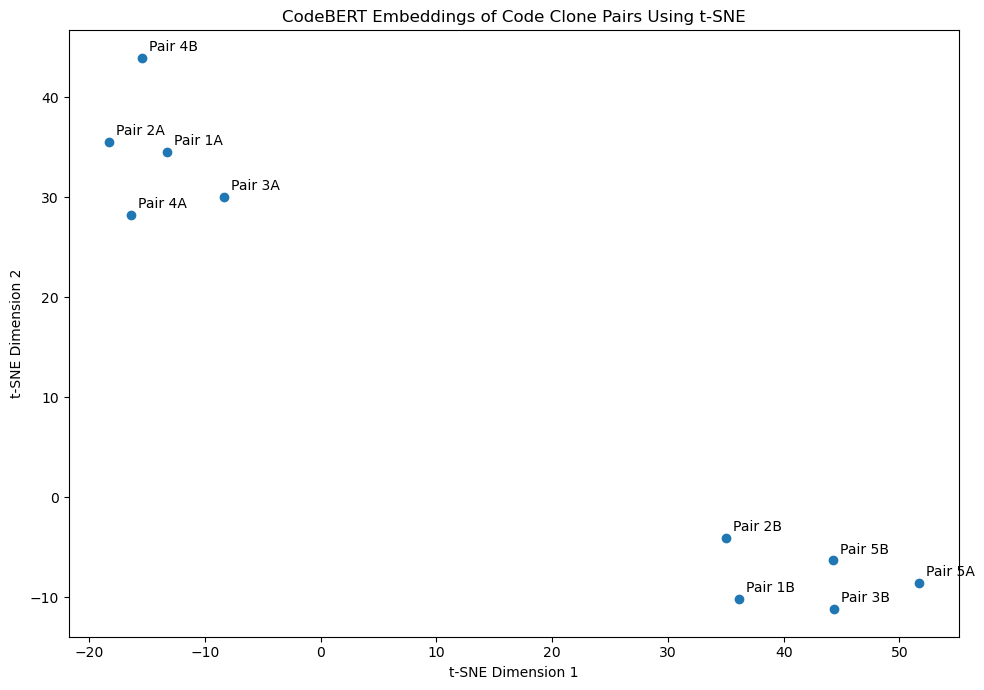

Pair 1: 66.5624
Pair 2: 66.3797
Pair 3: 66.8420
Pair 4: 15.7433
Pair 5: 7.7100


In [ ]:
# CSC 591 - TAI4SE 
# Homework 2
# Moe Ko

# This is my implementation for this assignment. My observations can be found in the README, as well as in some comments down below.

# Load the dataset

%pip install transformers datasets scikit-learn matplotlib seaborn

from datasets import load_dataset

dataset = load_dataset("google/code_x_glue_cc_clone_detection_big_clone_bench")

# Display dataset splits

print("Dataset Splits: ")
print(dataset)

for split in dataset:
    print(f"\nColumns in {split}: ")
    print(dataset[split].column_names)

print("\nFirst training example:")
print(dataset["train"][0])

# Inspect clone/non-clone labels in test set

label_counts = dataset["test"].to_pandas()["label"].value_counts()

print("Label counts in test set:")
print(label_counts)

print("\nExample labels:")
print(dataset["test"]["label"][:20])

# Select 5 clone pairs from test set

test_data = dataset["test"]

clone_pairs = []

for example in test_data:
    if example["label"] is True:
        clone_pairs.append(example)

    if len(clone_pairs) == 5:
        break

# Display the selected clone pairs

for i, pair in enumerate(clone_pairs, start = 1):
    print(f"\n{'=' * 60}")
    print(f"PAIR {i}") 
    print(f"{'=' * 60}")

    print(f"\nSnippet {i}A (id={pair['id1']}):")
    print(pair["func1"])

    print(f"\nSnippet {i}B (id={pair['id2']}):")
    print(pair["func2"])

    print(f"\nClone label: {pair['label']}")

# Short descriptions of each code pair and their function

# Pair 1: File copying. 1A uses FileChannel.transferTo while 1B uses a manual loop with recursion

# Pair 2 (mismatch): Copying a file using file chanels. 2A does direct transfers while 2B loads a config, copies file onto an SD card, then loads and boots a kernel

# Pair 3 (mismatch): Reads file and produces output. 3A reads file into string and prints it, while 3B reads the file, validates info, modifies data, and writes it to another file

# Pair 4: Hashing/Password encryption. Both use Java MessageDigest to hash a password, but 4B specifically uses SHA.

# Pair 5 (mismatch): 5A is for pdf signing while 5B is meant for converting medical images into a DICOM file.

# Load CodeBERT

%pip install -q torch

import torch

from transformers import AutoTokenizer, AutoModel

name = "microsoft/codebert-base"

tokenizer = AutoTokenizer.from_pretrained(name)

model = AutoModel.from_pretrained(name)

model.eval()

print("CodeBERT loaded")

# Test CodeBert Tokenization

test_code = clone_pairs[0]["func1"]

tokens = tokenizer.tokenize(test_code)

print("Original Code: ")
print(test_code)

print("\nFirst 50 tokens: ")
print(tokens[:50])

print(f"\nTotal number of tokens: {len(tokens)}")

# Generate CodeBERT output

inputs = tokenizer(test_code, return_tensors="pt", truncation = True, padding = True)

with torch.no_grad():
    outputs = model(**inputs)

print("Output shape: ")
print(outputs.last_hidden_state.shape)

# Display the tokenized input information.
print("Input IDs shape:", inputs["input_ids"].shape)
print("Attention mask shape:", inputs["attention_mask"].shape)

# Display the first 20 values of the attention mask.
print("\nFirst 20 attention mask values:")
print(inputs["attention_mask"][0][:20])

# Create Code Embedding function

# convert code snippet into one 768-dimensional embedding
def create_code_embedding(code):

    # tokenize code
    inputs = tokenizer(code, return_tensors = "pt", truncation = True, padding = True)

    # generate CodeBERT token representations
    with torch.no_grad():
        outputs = model(**inputs)

    # get token embeddings
    token_embeddings = outputs.last_hidden_state

    # get attention mask
    attention_mask = inputs["attention_mask"]

    # expand attention mask to have same dimensions as token embeddings
    mask = attention_mask.unsqueeze(-1).expand(token_embeddings.size()).float()

    # remove padding tokens and calculate mean remaining token embeddings
    summed_embeddings = torch.sum(token_embeddings * mask, dim = 1)
    summed_mask = torch.clamp(mask.sum(dim = 1), min = 1e-9)

    # Final embedding
    embedding = summed_embeddings / summed_mask

    return embedding.squeeze(0)

# Generate an embedding for the first snippet of Pair 1. 
 
test_embedding = create_code_embedding(clone_pairs[0]["func1"]) 

# Display its shape.
print("Embedding shape:")
print(test_embedding.shape) 

# Display the first 10 values.
print("\nFirst 10 values of the embedding:") 
print(test_embedding[:10])

# Generate embeddings for all snippets

embeddings = []
snippet_labels = []

for pair_number, pair in enumerate(clone_pairs, start = 1):

    embedding_A = create_code_embedding(pair["func1"])
    embeddings.append(embedding_A)

    snippet_labels.append(f"Pair {pair_number}A")

    embedding_B = create_code_embedding(pair["func2"])
    embeddings.append(embedding_B)
    
    snippet_labels.append(f"Pair {pair_number}B")

# Stack embeddings into one tensor

embeddings = torch.stack(embeddings)

print("\nEmbedding matrix shape:")
print(embeddings.shape)

print("\nSnippet labels:")
print(snippet_labels)

# Convert CodeBERT embeddings from PyTorch tensor to NumPy array

embeddings_NP = embeddings.numpy()

print("\nEmbedding matrix shape:")
print(embeddings_NP.shape)

# Import t-SNE

from sklearn.manifold import TSNE

# Reduce 768-dimensional CodeBERT embeddings to 2 dimensions with TSNE
tsne = TSNE(
    n_components=2,
    perplexity=3,
    random_state=42
)

embeddings_2d = tsne.fit_transform(embeddings_NP)

print("t-SNE output shape:")
print(embeddings_2d.shape)

# Print result coordinates

for label, coordinates in zip(snippet_labels, embeddings_2d):
    print(f"{label}: x={coordinates[0]:.4f}, y={coordinates[1]:.4f}")

# Plot visualization

import os
import matplotlib.pyplot as plt

plt.figure(figsize = (10, 7))

plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1])

for i, label in enumerate(snippet_labels):
    plt.annotate(
        label,
        (embeddings_2d[i, 0], embeddings_2d[i, 1]),
        xytext=(5, 5),
        textcoords="offset points"
    )

plt.title("CodeBERT Embeddings of Code Clone Pairs Using t-SNE")
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")

plt.tight_layout()

os.makedirs("graph", exist_ok = True)
plt.savefig("graph/tsne_embeddings.png", dpi = 300, bbox_inches = "tight")

plt.show()

# Visualization analysis

# Pairs 1, 2, and 3 are quite far apart and seem to have 2 clusters based on A and B
# Pairs 4 and 5 are somewhat close to each other

# Distance between snippets in each pair

import numpy as np

pair_distances = []

for i in range(5):
    point_a = embeddings_2d[2 * i]
    point_b = embeddings_2d[2 * i + 1]

    distance = np.linalg.norm(point_a - point_b)
    pair_distances.append(distance)

    print(f"Pair {i + 1}: {distance:.4f}")

